In [1]:
import torch
print(torch.cuda.is_available())   # → True
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [2]:
import numpy as np
import re

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from IPython.display import Video

from stable_baselines3 import SAC, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback

import glob
from datetime import datetime

import os
#os.environ["MUJOCO_GL"] = "glfw"

<p>
  <img src="Humanoid.png" alt="Humanoid" width="800">
</p>

In [3]:
def Record_Video(model, path_videos):
    os.makedirs(path_videos, exist_ok=True)
    
    record_env = gym.make("Humanoid-v5", render_mode="rgb_array")
    record_env = RecordVideo(record_env, path_videos , episode_trigger=lambda x: True)

    obs, _ = record_env.reset()

    max_videos = 3
    k = 0
    for _ in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = record_env.step(action)

        if done or truncated:
            k += 1
            obs, _ = record_env.reset()
            if k >= max_videos:
                break

    record_env.close()

In [4]:
env = make_vec_env("Humanoid-v5", n_envs=8)

# Configuiraciones: load determina si se carga o no, checkpoint que tipo de carga, y train_* son para los modelos
load = False             # para reanudar entrenamiento             
checkpoint = True       # para reanuder entrenamiento desde checkpoint
train_SAC = False        # para entrenar con SAC
train_TD3 = True       # para entrenar con TD3

time_steps = 20_000_000
eval_parts = 20
part = time_steps / eval_parts

checkpoint_dir = "./checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)

sac_dir = "./sac_models/"
os.makedirs(sac_dir, exist_ok=True)

td3_dir = "./td3_models/"
os.makedirs(td3_dir, exist_ok=True)

fecha = datetime.now().strftime("%Y%m%d")

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=checkpoint_dir,
    name_prefix="sac_ckp" if train_SAC else "td3_ckp"
)

try:
    if train_SAC and not load:
        print("🚀 Iniciando entrenamiento SAC...")
        model = SAC(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            model.save(checkpoint_dir + "sac_ckp_" + str( i * part) + f"_{fecha}")
            
            Record_Video(model, (checkpoint_dir + "/videos_sac_" + str( i * part) + f"_{fecha}"))            
            
        model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + f"_{fecha}")

    elif train_TD3 and not load:
        print("🚀 Iniciando entrenamiento TD3...")
        n_actions = env.action_space.shape[0]
        action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
        model = TD3(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99,
            action_noise=action_noise, policy_delay=2,
            target_policy_noise=0.2, target_noise_clip=0.5
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            model.save(checkpoint_dir + "td3_ckp_" + str( i * part) + f"_{fecha}")
            
            Record_Video(model, (checkpoint_dir + "/videos_td3_" + str( i * part) + f"_{fecha}"))            
            
        model.save(td3_dir + "td3_humanoid_final_" + str(time_steps) + f"_{fecha}")

    else:

        print("📂 Cargando modelo SAC para reanudar...")
        if train_SAC:
            # Entra al modo recuperacion
            
            # comprueba y adquiere los archivos de checkpoint
            ckpt_files = glob.glob("./checkpoints/sac_ckp_*_steps.zip")
            if not ckpt_files:
                raise FileNotFoundError("No se encontraron checkpoints en ./checkpoints/")
            
            # elige el de mayor numero de steps
            latest_ckpt = max(ckpt_files, key=lambda f: int(re.search(r'(\d+)_steps\.zip$', f).group(1)))
            print("Debug latest chkpoint: ", latest_ckpt)
            
            if (checkpoint == True):
                model = SAC.load(latest_ckpt, env=env)
                #model.set_env(env)
                
                print("✅ Reanudando entrenamiento desde checkpoint...")
                
                model.learn(
                    total_timesteps=time_steps, 
                    progress_bar=True, 
                    callback=checkpoint_callback,
                    reset_num_timesteps=False 
                )
                
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + f"_{fecha}")
            else:
                # -----------------------probar
                model = SAC.load(sac_dir + "sac_humanoid_final")
                model.set_env(env)
                
                print("✅ Reanudando entrenamiento desde modelo entrenado...")
                
                model.learn(
                    total_timesteps=time_steps, 
                    progress_bar=True, 
                    callback=checkpoint_callback,
                    reset_num_timesteps=False
                )
                
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps)  + f"_{fecha}")
        else:
            # -----------------------probar
            print("📂 Cargando modelo TD3 para reanudar...")
            #model = TD3.load("td3_humanoid_final")


except KeyboardInterrupt:
    print("\n⏹️ Entrenamiento interrumpido manualmente.")
    model.save(("sac_humanoid_last"  + f"_{fecha}") if train_SAC else ("td3_humanoid_last"  + f"_{fecha}"))
    print("💾 Estado guardado. Ejecuta de nuevo con `load = True` para continuar.")

finally:
    env.close()
    print("🏁 Entorno cerrado.")

🚀 Iniciando entrenamiento TD3...


Output()

i:  0


c:\Users\Alfonso\Documents\TFM\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Alfonso\Documents\TFM\checkpoints\videos_td3_0.0_20260504 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Output()

...

c:\Users\Alfonso\Documents\TFM\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Alfonso\Documents\TFM\checkpoints\videos_td3_900000.0_20260504 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Output()

i:  19


c:\Users\Alfonso\Documents\TFM\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Alfonso\Documents\TFM\checkpoints\videos_td3_950000.0_20260504 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


🏁 Entorno cerrado.


In [5]:
path_videos = "./videos_trained"

In [6]:
env = gym.make("Humanoid-v5", render_mode="rgb_array")
env = RecordVideo(env, path_videos, episode_trigger=lambda x: True)

obs, _ = env.reset()

for _ in range(2000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, _ = env.step(action)

    if done or truncated:
        obs, _ = env.reset()
        break

env.close()

c:\Users\Alfonso\Documents\TFM\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Alfonso\Documents\TFM\videos_trained folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [7]:
# Busca el primer vídeo generado
video_file = []
for file in os.listdir(path_videos):
    print("file: ", file)
    if file.endswith(".mp4"):
        video_file.append( os.path.join(path_videos, file))

file:  rl-video-episode-0.mp4
file:  rl-video-episode-1.mp4
file:  rl-video-episode-2.mp4


In [8]:
Video(video_file[0], embed=True)

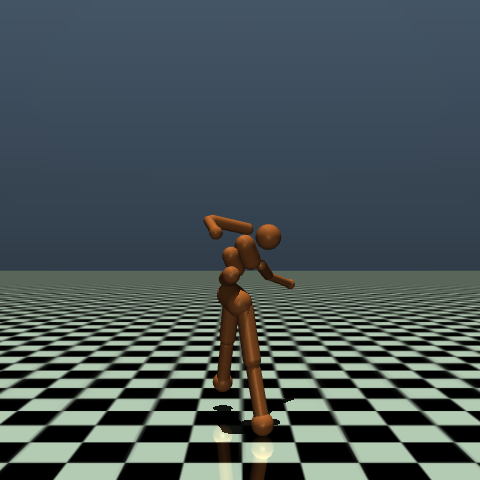

In [9]:
import gymnasium as gym
from IPython.display import display, clear_output
from PIL import Image as PILImage
import time

# 1. Crear entorno con renderizado en formato imagen
env = gym.make("Humanoid-v5", render_mode="rgb_array")
obs, info = env.reset()

# 2. Bucle de simulación
for step in range(300):  # Ajusta según necesites (300 ~ 5-6 segundos)
    action, _ = model.predict(obs, deterministic=True)#env.action_space.sample()  # ← Reemplaza por tu política/agente
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    if frame is not None:
        clear_output(wait=True)  # Limpia la celda sin parpadeo
        display(PILImage.fromarray(frame))

    if terminated or truncated:
        obs, info = env.reset()

    time.sleep(0.03)  # Controla la velocidad de reproducción

env.close()